### 🌱 课前准备




#### 📦 所需环境（和上一个环境一样。就不用进行这一步了）

```bash
conda create -n ann python=3.9
conda activate ann
pip install numpy pandas matplotlib scikit-learn seaborn
```

In [41]:
print("hello")
import sys
print(sys.executable)

hello
/opt/anaconda3/bin/python


### 📖 2.1 背景知识



#### 1. 什么是人工神经网络（ANN）？
- **灵感来源**：模仿人类大脑神经元的工作方式，由大量“人工神经元”相互连接组成。
- **核心作用**：处理复杂的非线性关系，擅长从数据中“学习”规律。
- **应用场景**：图像识别、语音处理、预测任务（比如房价预测）等。



#### 2. 神经元的基本结构（类比烧水）：
- **输入**：水温、电压、水量（类似数据特征）
- **权重**：每个输入的重要程度（比如电压对烧水速度的影响更大）
- **激活函数**：决定是否“触发”输出（比如水温达到100℃才输出“水开了”）



#### 3. 网络结构（以本次实验的简单网络为例）：
- **输入层**：接收原始数据（比如房价的13个特征）
- **隐藏层**：多层神经元，逐层提取数据特征（类似“先看房子面积，再结合房间数判断价值”）
- **输出层**：给出预测结果（房价数值）



#### 4. 训练过程（类比学骑自行车）：
1. **随机猜测**：先随便定一个“骑车姿势”（随机初始化权重）
2. **发现误差**：摔了！实际结果和目标（不摔）有差距（计算预测值与真实值的误差）
3. **调整策略**：把姿势调正一点（反向传播算法优化权重）
4. **反复练习**：多次迭代直到误差足够小（训练多个epoch）



#### 5. 常见激活函数：

激活函数在神经网络中的作用，可以类比为生物神经元的激活阈值。它们决定了网络中的信息是否和如何传递，进而影响网络对复杂数据模式的学习能力。但与生物神经元的直接电信号传递不同，激活函数在神经网络中引入了数学上的非线性，使得网络能够捕捉和学习数据中的复杂结构和关系。

![常见激活函数](https://pic2.zhimg.com/v2-8d16400b4e52d73a521cbfc97a87bf31_1440w.jpg)



1. **Sigmoid激活函数** Sigmoid的特性是将输入内容压缩到（0,1）之间，当x为0时，输出中间结果0.5，函数中心点在（0，0.5）的位置；

当x取绝对值很大的正值的时候，Sigmoid激活函数会饱和到一个高值（无限趋近于1）；当x取绝对值很大的负值的时候，Sigmoid激活函数会饱和到一个低值（无限趋近于0）。: 

![](https://i-blog.csdnimg.cn/blog_migrate/6c4aa7810ea357bb8e4766691b6119e5.png) 



2. **ReLU激活函数(Rectified Linear Unit)**：`f(x) = max(0, x)`，解决传统Sigmoid的梯度消失问题（当 x 大于 0 时，ReLU 的梯度恒为 1，不会随着网路深度的加深而使得梯度在累乘的时候变得越来越小或者越来越大，从而不会发生梯度消失或梯度爆炸。);有效缓解过拟合的问题，因为 ReLU 有可能使部分神经节点的输出变为 0，从而导致神经节点死亡，降低了神经网络的复杂度;

![](https://i-blog.csdnimg.cn/blog_migrate/bfe6383c38e8378ba8dad628b73455f3.png) 

In [7]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, auc, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


### 📖 2.2 ANN 分类 (iris数据集为例)

#### 加载鸢尾花数据集

In [42]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

#### 数据预处理

In [43]:
# 划分训练集和测试集
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)
# 标准化
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

#### 构建 ANN 分类模型并进行交叉验证

这里使用 MLPClassifier 创建一个具有两个隐藏层（分别有 10 个和 5 个神经元）的神经网络，max_iter 表示最大训练迭代次数。交叉验证用于更可靠地评估模型性能。

In [45]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

# 创建多层感知机分类器
# loss是由solver决定的，对分类问题来说就是 cross-entropy loss 
mlp_iris = MLPClassifier(hidden_layer_sizes=(10, 5), 
                        solver='adam',
                        # verbose=True,#显示训练过程loss
max_iter=1000, random_state=42)

# 交叉验证评估模型
scores = cross_val_score(mlp_iris, X_train, y_train, cv=5)
print("Cross - validation scores:", scores)
print("Average cross - validation score:", scores.mean())

# 训练模型并预测
mlp_iris.fit(X_train, y_train)
y_pred = mlp_iris.predict(X_test)
# loss = mlp_iris.loss_curve_



####################################
# 可选择将模型保存在本地，下次直接加载无需训练
from joblib import dump, load
import os

# 1. 保存模型
# 创建保存目录（如果不存在）
model_dir = "saved_models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 保存模型
model_path = os.path.join(model_dir, "model1.joblib")
dump(mlp_iris, model_path)
print(f"模型已保存到: {model_path}")

# 2. 加载模型并预测
# 加载模型
loaded_model = load(model_path)

# 使用加载的模型进行预测
new_predictions = loaded_model.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Cross - validation scores: [0.95238095 0.95238095 0.9047619  1.         1.        ]
Average cross - validation score: 0.9619047619047618
模型已保存到: saved_models/model1.joblib


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


#### 绘制 ROC 曲线

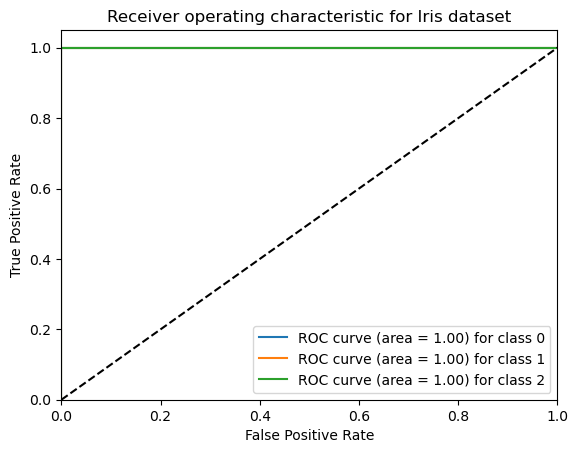

In [17]:
# 计算 ROC 曲线
y_score = mlp_iris.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(np.unique(y_test))):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制 ROC 曲线
plt.figure()
for i in range(len(np.unique(y_test))):
    plt.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f) for class %d' % (roc_auc[i], i))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for Iris dataset')
plt.legend(loc="lower right")
plt.show()


ROC 曲线用于评估分类模型在不同阈值下的性能，曲线下面积（AUC）越大，模型性能越好。

### 📖 2.3 ANN 分类（特征选择和提取）

##### 特征选择（ANOVA）

In [18]:
selector = SelectKBest(score_func=f_classif, k=2)
X_iris_selected = selector.fit_transform(X_iris, y_iris)

In [19]:
X_train_selected, X_test_selected, y_train, y_test = train_test_split(X_iris_selected, y_iris, test_size=0.3, random_state=42)


In [20]:
mlp_iris_selected = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42)
mlp_iris_selected.fit(X_train_selected, y_train)
y_pred_selected = mlp_iris_selected.predict(X_test_selected)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


- ROC曲线

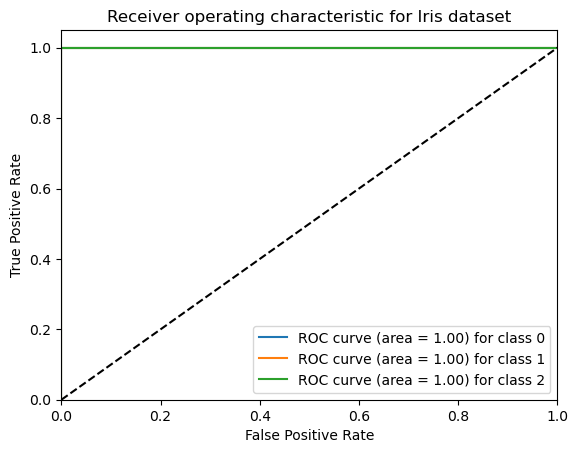

In [21]:
# 计算 ROC 曲线
y_score = mlp_iris_selected.predict_proba(X_test_selected)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(np.unique(y_test))):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制 ROC 曲线
plt.figure()
for i in range(len(np.unique(y_test))):
    plt.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f) for class %d' % (roc_auc[i], i))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for Iris dataset')
plt.legend(loc="lower right")
plt.show()


##### 特征提取（以 PCA 为例）

In [22]:
# PCA 降维到 2 维
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris)

# 划分训练集和测试集
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_iris_pca, y_iris, test_size=0.3, random_state=42)

# 创建多层感知机分类器并训练
mlp_iris_pca = MLPClassifier(hidden_layer_sizes=(10, 5),verbose = True, max_iter=1000, random_state=42)
mlp_iris_pca.fit(X_train_pca, y_train)
y_pred_pca = mlp_iris_pca.predict(X_test_pca)

Iteration 1, loss = 1.44825555
Iteration 2, loss = 1.44458375
Iteration 3, loss = 1.44092941
Iteration 4, loss = 1.43729236
Iteration 5, loss = 1.43367388
Iteration 6, loss = 1.43007351
Iteration 7, loss = 1.42648599
Iteration 8, loss = 1.42291891
Iteration 9, loss = 1.41937728
Iteration 10, loss = 1.41585347
Iteration 11, loss = 1.41234951
Iteration 12, loss = 1.40886877
Iteration 13, loss = 1.40540870
Iteration 14, loss = 1.40195933
Iteration 15, loss = 1.39852258
Iteration 16, loss = 1.39509738
Iteration 17, loss = 1.39168495
Iteration 18, loss = 1.38828975
Iteration 19, loss = 1.38490882
Iteration 20, loss = 1.38153758
Iteration 21, loss = 1.37817932
Iteration 22, loss = 1.37483145
Iteration 23, loss = 1.37149282
Iteration 24, loss = 1.36816391
Iteration 25, loss = 1.36484239
Iteration 26, loss = 1.36152778
Iteration 27, loss = 1.35821958
Iteration 28, loss = 1.35491725
Iteration 29, loss = 1.35162089
Iteration 30, loss = 1.34832970
Iteration 31, loss = 1.34504294
Iteration 32, los

- ROC曲线

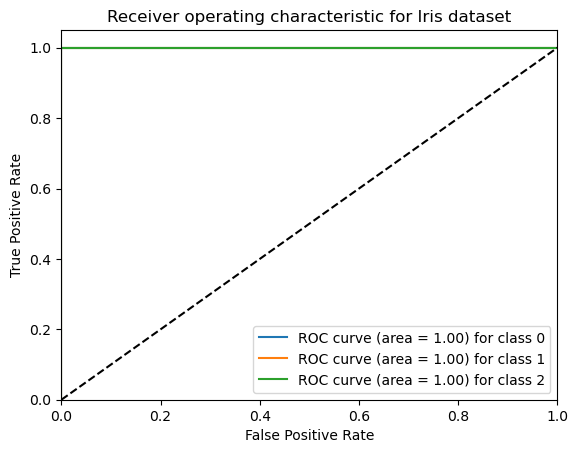

In [23]:
# 计算 ROC 曲线
y_score = mlp_iris_pca.predict_proba(X_test_pca)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(np.unique(y_test))):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制 ROC 曲线
plt.figure()
for i in range(len(np.unique(y_test))):
    plt.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f) for class %d' % (roc_auc[i], i))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for Iris dataset')
plt.legend(loc="lower right")
plt.show()


### 📖 2.4 ANN 分类使用不同激活函数、输出层和学习模型

In [24]:
# 创建使用不同激活函数的 MLP 分类器
mlp_sigmoid = MLPClassifier(hidden_layer_sizes=(10, 5), activation='logistic', max_iter=1000, random_state=42)
mlp_relu = MLPClassifier(hidden_layer_sizes=(10, 5), activation='relu', max_iter=1000, random_state=42)

# 训练并评估
mlp_sigmoid.fit(X_train, y_train)
mlp_relu.fit(X_train, y_train)

score_sigmoid = mlp_sigmoid.score(X_test, y_test)
score_relu = mlp_relu.score(X_test, y_test)

print("Score with sigmoid activation:", score_sigmoid)
print("Score with relu activation:", score_relu)

Score with sigmoid activation: 0.9777777777777777
Score with relu activation: 0.9777777777777777


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


### 📖 2.5 ANN 回归（以加州房价数据集为例）

#### 🔍 第一步：认识我们的数据（加州房价）


##### 📊 数据集说明
| 特征名称       | 含义                     | 类型   |
|----------------|--------------------------|--------|
| MedInc         | 街区收入中位数           | 数值   |
| HouseAge       | 房屋年龄中位数           | 数值   |
| AveRooms       | 平均房间数（含卧室）     | 数值   |
| AveBedrms      | 平均卧室数               | 数值   |
| Population     | 街区人口                 | 数值   |
|  AveOccup |每个住宅单元的平均住户人数 | 数值 |
| Latitude       | 纬度（地理坐标）         | 数值   |
| Longitude      | 经度（地理坐标）         | 数值   |
| **MedHouseVal**| **目标值：房价中位数**   | 数值   |

⚠️ 注意：数据已按街区聚合，适合区域房价预测

In [25]:
# 加载数据集（自动下载）
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=['MedHouseVal'])

# 合并特征和标签，方便查看
df = pd.concat([X, y], axis=1)
print("数据前5行：")
display(df.head())  # 用Jupyter友好的表格展示

数据前5行：


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


##### 🔍 数据初印象
运行下面代码，观察：
1. 房价（MedHouseVal）的分布（为什么大部分在0-5之间？因为单位是$100,000）
2. 收入（MedInc）和房价的关系（明显正相关）
3. 房间数（AveRooms）和卧室数（AveBedrms）的关系（可以计算『平均房间/卧室比』）

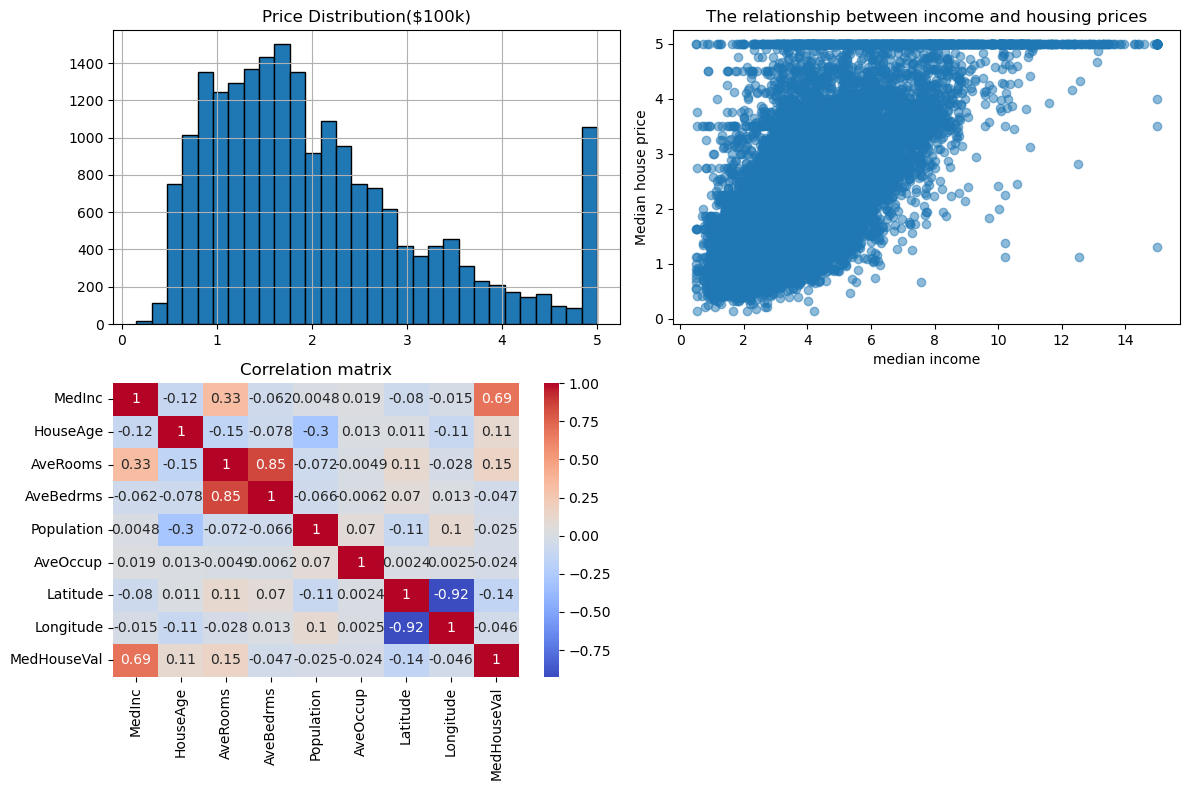

In [26]:
import seaborn as sns
# 绘制特征分布和相关性
plt.figure(figsize=(12, 8))

# 房价分布（直方图）
plt.subplot(2, 2, 1)
df['MedHouseVal'].hist(bins=30, edgecolor='black')
plt.title('Price Distribution($100k)')

# 收入vs房价（散点图）
plt.subplot(2, 2, 2)
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.5)
plt.xlabel('median income')
plt.ylabel('Median house price')
plt.title('The relationship between income and housing prices')

# 特征相关性热图
plt.subplot(2, 2, 3)
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation matrix')

plt.tight_layout()
plt.show()

这组图表展示了与加州房价相关的数据特征及变量间关系：
1. 左上角：房价分布直方图（Price Distribution($100k)）
    - **横坐标**：房价中位数（单位为10万美元 ），范围从0到5 。
    - **纵坐标**：样本数量。
    - **含义**：呈现加州房价中位数的分布情况。可以看出大部分房价集中在10 - 25万美元区间，有一个小高峰在更高价位段，说明大部分区域房价处于中等水平，但也有部分高房价区域 。 
2. 右上角：收入与房价关系散点图（The relationship between income and housing prices）
    - **横坐标**：收入中位数。
    - **纵坐标**：房价中位数。
    - **含义**：散点表示不同区域的收入与房价对应关系。整体上呈现出正相关趋势，即收入中位数较高的区域，房价中位数也倾向于更高 。 
3. 下方：相关性矩阵热图（Correlation matrix）
    - **行列标签**：代表不同变量，包括MedInc（收入中位数）、HouseAge（房屋年龄中位数 ）、AveRooms（平均房间数 ）、AveBedrms（平均卧室数 ）、Population（人口 ）、AveOccup（平均入住率 ）、Latitude（纬度）、Longitude（经度）、MedHouseVal（房价中位数） 。
    - **颜色**：颜色越红表示正相关性越强（值接近1 ），颜色越蓝表示负相关性越强（值接近 - 1 ），颜色越浅表示相关性越弱（值接近0 ）。
    - **重点关系**
        - MedInc与MedHouseVal相关性为0.69 ，说明收入和房价有较明显正相关。
        - AveRooms与AveBedrms相关性达0.85 ，表明平均房间数和平均卧室数关联紧密。
        - Latitude与Longitude相关性为 - 0.92 ，说明经纬度之间有很强负相关（地理坐标特性 ）。 

#### 🧠 第二步：数据预处理



In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
# 👷 数据预处理（神经网络的『洗菜步骤』）
# 1. 划分训练集和测试集（70%训练，30%测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42  # random_state固定随机种子，保证结果可复现
)

# 2. 特征标准化（让所有特征在相同尺度上）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔍 为什么需要标准化？
# 比如收入（0-15）和纬度（32-42）尺度不同，会让神经网络学习困难

#### 🚀 第三步：搭建神经网络 train!


##### 神经元：最简单的计算单元



![神经元示意图](https://via.placeholder.com/200x100?text=输入×权重+偏差→激活函数)
**数学公式**：`output = activation(inputs·weights + bias)`
**类比**：奶茶定价 = 成本×1.5（权重） + 地段加成2元（偏差），超过20元就加珍珠（激活函数）


##### 网络结构：3层神经网络



输入层（7个特征）→ 隐藏层（10个神经元）→ 输出层（1个预测值）
**为什么需要隐藏层？** 比如判断房价时，隐藏层可以自动学习『人均房间数=AveRooms/AveBedrms』这种衍生特征

##### 🏗️ 网络结构说明


| 层类型       | 神经元数 | 激活函数 | 作用                     |
|--------------|----------|----------|--------------------------|
| 输入层       | 7        | 无       | 接收7个特征             |
| 隐藏层1      | 10       | ReLU     | 学习非线性特征           |
| 隐藏层2      | 5        | ReLU     | 减少复杂度（防止过拟合）|
| 输出层       | 1        | 线性     | 回归任务，直接输出数值   |

##### 代码实现

运行下面代码后，注意观察：
1. 损失值（Loss）如何下降（理想情况：逐渐降低）
2. 训练集和验证集的损失差异（差异过大可能过拟合）

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Iteration 1, loss = 1.58164177
Iteration 2, loss = 1.00472618
Iteration 3, loss = 0.68399128
Iteration 4, loss = 0.51697365
Iteration 5, loss = 0.43848850
Iteration 6, loss = 0.39556547
Iteration 7, loss = 0.36294237
Iteration 8, loss = 0.33435579
Iteration 9, loss = 0.31517233
Iteration 10, loss = 0.29985474
Iteration 11, loss = 0.28694844
Iteration 12, loss = 0.27562298
Iteration 13, loss = 0.26517517
Iteration 14, loss = 0.25544363
Iteration 15, loss = 0.24672932
Iteration 16, loss = 0.23917932
Iteration 17, loss = 0.23328984
Iteration 18, loss = 0.22852635
Iteration 19, loss = 0.22462900
Iteration 20, loss = 0.22120553
Iteration 21, loss = 0.21809554
Iteration 22, loss = 0.21549769
Iteration 23, loss = 0.21281322
Iteration 24, loss = 0.20986829
Iteration 25, loss = 0.20715806
Iteration 26, loss = 0.20412753
Iteration 27, loss = 0.20204047
Iteration 28, loss = 0.20023689
Iteration 29, loss = 0.19856283
Iteration 30, loss = 0.19694254
Iteration 31, loss = 0.19547439
Iteration 32, los

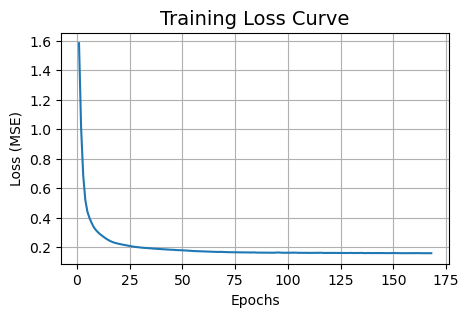

In [29]:

# 使用MLPRegressor搭建模型
model = MLPRegressor(
    hidden_layer_sizes=(10, 5),  # 两个隐藏层，分别有10和5个神经元
    verbose=True,#显示训练过程loss
    activation='relu',  # 激活函数为ReLU
    solver='adam',  # 优化器为adam，类似智能版梯度下降
    max_iter=500,  # 最大迭代次数，可根据情况调整
    random_state=42  # 固定随机种子，保证结果可复现
)

# 训练模型
model.fit(X_train_scaled, y_train)

# 打印模型结构（MLPRegressor没有类似summary的直接方法，这里打印参数）
print(model.get_params())




# 训练完成后可以直接获取loss曲线数据
loss_curve = model.loss_curve_

# 绘制loss曲线
plt.figure(figsize=(5,3))
plt.plot(range(1, len(loss_curve)+1), loss_curve)
plt.title("Training Loss Curve", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

#### 测试评估

测试集均方误差：0.3177


Text(0.5, 1.0, 'comparison')

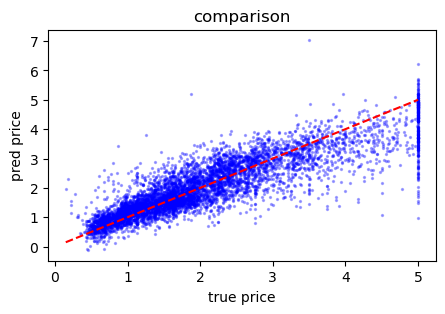

In [30]:
# 测试集评估
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test_scaled)
test_loss = mean_squared_error(y_test, y_pred)
print(f"测试集均方误差：{test_loss:.4f}")

# 预测结果可视化
plt.figure(figsize=(5,3))
plt.scatter(y_test, y_pred, s=2,c='b',alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 理想对角线
plt.xlabel('true price')
plt.ylabel('pred price')
plt.title('comparison')
# plt.show()


### 📖 2.6 ANN 回归（特征选择和提取）

##### 特征选择(ANOVA)

In [31]:
selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X, y)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [32]:
X_train_selected, X_test_selected, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)


In [33]:

mlp_selected = MLPRegressor(
    hidden_layer_sizes=(10, 5),  # 两个隐藏层，分别有10和5个神经元
    verbose=True,#显示训练过程loss
    activation='relu',  # 激活函数为ReLU
    solver='sgd',  # 优化器为adam，类似智能版梯度下降
    max_iter=5000,  # 最大迭代次数，可根据情况调整
    random_state=42  # 固定随机种子，保证结果可复现
)
mlp_selected.fit(X_train_selected, y_train)
y_pred_selected = mlp_selected.predict(X_test_selected)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Iteration 1, loss = 1.61720458
Iteration 2, loss = 0.53789674
Iteration 3, loss = 0.40916613
Iteration 4, loss = 0.36460639
Iteration 5, loss = 0.36507384
Iteration 6, loss = 0.36358337
Iteration 7, loss = 0.36395052
Iteration 8, loss = 0.36410649
Iteration 9, loss = 0.36363834
Iteration 10, loss = 0.36335808
Iteration 11, loss = 0.36316898
Iteration 12, loss = 0.36339751
Iteration 13, loss = 0.36295268
Iteration 14, loss = 0.36295650
Iteration 15, loss = 0.36349071
Iteration 16, loss = 0.36237254
Iteration 17, loss = 0.36333290
Iteration 18, loss = 0.36349012
Iteration 19, loss = 0.36297800
Iteration 20, loss = 0.36243345
Iteration 21, loss = 0.36261303
Iteration 22, loss = 0.36206263
Iteration 23, loss = 0.36140230
Iteration 24, loss = 0.36158047
Iteration 25, loss = 0.36157111
Iteration 26, loss = 0.36137834
Iteration 27, loss = 0.36101956
Iteration 28, loss = 0.36147706
Iteration 29, loss = 0.36052786
Iteration 30, loss = 0.36145929
Iteration 31, loss = 0.36132318
Iteration 32, los

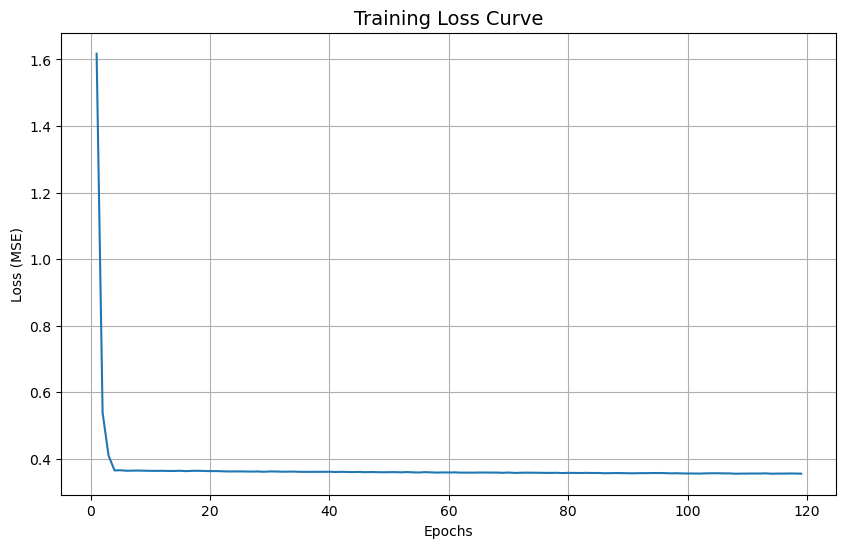

In [34]:
loss_curve = mlp_selected.loss_curve_

# 绘制loss曲线
plt.figure(figsize=(10,6))
plt.plot(range(1, len(loss_curve)+1), loss_curve)
plt.title("Training Loss Curve", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

- 测试评估

测试集均方误差：0.7238


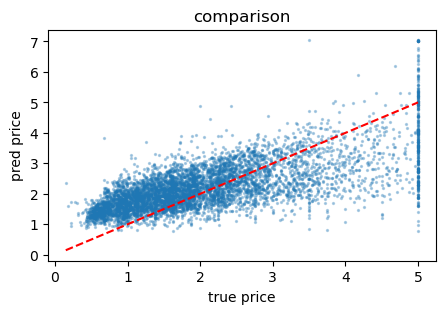

In [35]:

# 测试集评估
from sklearn.metrics import mean_squared_error

y_pred = mlp_selected.predict(X_test_selected)
test_loss = mean_squared_error(y_test, y_pred)
print(f"测试集均方误差：{test_loss:.4f}")

# 预测结果可视化
plt.figure(figsize=(5,3))
plt.scatter(y_test, y_pred, alpha=0.3,s=2)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 理想对角线
plt.xlabel('true price')
plt.ylabel('pred price')
plt.title('comparison')
plt.show()


##### 特征提取（以 PCA 为例）

In [36]:
# PCA 降维到 2 维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 划分训练集和测试集
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 创建多层感知机分类器并训练
mlp_pca = MLPRegressor(hidden_layer_sizes=(10, 5),
                    verbose=True,
                    max_iter=1000, random_state=42)
mlp_pca.fit(X_train_pca, y_train)
y_pred_pca = mlp_pca.predict(X_test_pca)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Iteration 1, loss = 547.02077102
Iteration 2, loss = 5.37260313
Iteration 3, loss = 4.22198969
Iteration 4, loss = 3.39072489
Iteration 5, loss = 2.95386869
Iteration 6, loss = 2.61203273
Iteration 7, loss = 2.54654321
Iteration 8, loss = 2.47737646
Iteration 9, loss = 2.29505759
Iteration 10, loss = 2.21207648
Iteration 11, loss = 2.09561866
Iteration 12, loss = 2.16703071
Iteration 13, loss = 2.01861419
Iteration 14, loss = 2.04437386
Iteration 15, loss = 1.90549524
Iteration 16, loss = 1.85299639
Iteration 17, loss = 1.62304463
Iteration 18, loss = 1.67658204
Iteration 19, loss = 1.40576846
Iteration 20, loss = 1.40120505
Iteration 21, loss = 1.29687501
Iteration 22, loss = 1.24400464
Iteration 23, loss = 1.16511231
Iteration 24, loss = 1.11819530
Iteration 25, loss = 0.93137905
Iteration 26, loss = 0.98364616
Iteration 27, loss = 1.02074562
Iteration 28, loss = 0.83524064
Iteration 29, loss = 0.84458865
Iteration 30, loss = 1.18367769
Iteration 31, loss = 1.02617268
Iteration 32, l

测试集均方误差：1.4695


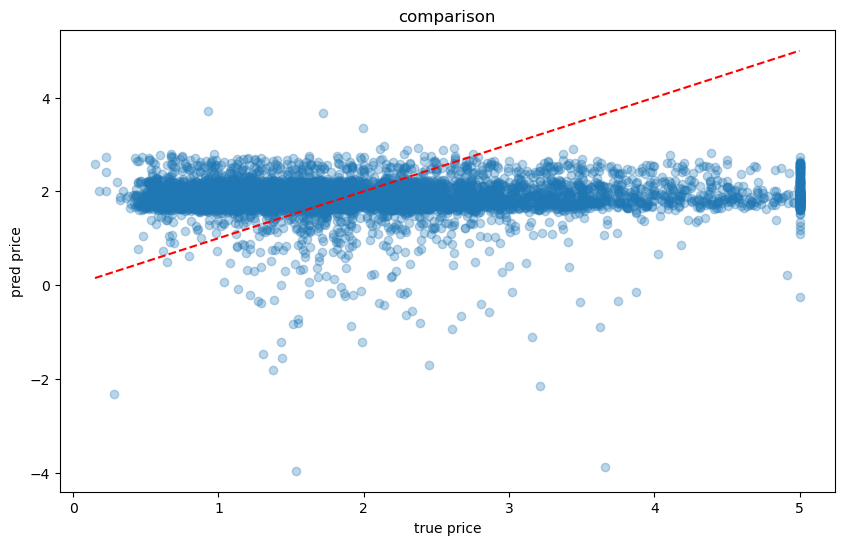

In [37]:

# 测试集评估
from sklearn.metrics import mean_squared_error

y_pred = mlp_pca.predict(X_test_pca)
test_loss = mean_squared_error(y_test, y_pred)
print(f"测试集均方误差：{test_loss:.4f}")

# 预测结果可视化
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 理想对角线
plt.xlabel('true price')
plt.ylabel('pred price')
plt.title('comparison')
plt.show()


### 📖 2.7 ANN 回归使用不同激活函数、输出层和学习模型

In [38]:
# 创建使用不同激活函数的 MLP 分类器
mlp_sigmoid = MLPRegressor(hidden_layer_sizes=(10, 5),
                        verbose=True,
                        activation='logistic', max_iter=1000, random_state=42)
mlp_relu = MLPRegressor(hidden_layer_sizes=(10, 5), 
                        verbose=True,
                        activation='relu', max_iter=1000, random_state=42)

# 训练并评估
mlp_sigmoid.fit(X_train, y_train)
mlp_relu.fit(X_train, y_train)

# score_sigmoid = mlp_sigmoid.score(X_test, y_test)
# score_relu = mlp_relu.score(X_test, y_test)

# print("Score with sigmoid activation:", score_sigmoid)
# print("Score with relu activation:", score_relu)

y_pred_sigmoid = mlp_sigmoid.predict(X_test_scaled)
y_pred_relu = mlp_relu.predict(X_test_scaled)

test_loss_sigmoid = mean_squared_error(y_test, y_pred_sigmoid)
test_loss_relu = mean_squared_error(y_test, y_pred_relu)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Iteration 1, loss = 2.49892536
Iteration 2, loss = 1.87708042
Iteration 3, loss = 1.41480436
Iteration 4, loss = 1.09876925
Iteration 5, loss = 0.92128419
Iteration 6, loss = 0.81178126
Iteration 7, loss = 0.75074492
Iteration 8, loss = 0.71599405
Iteration 9, loss = 0.69530867
Iteration 10, loss = 0.68326535
Iteration 11, loss = 0.67664480
Iteration 12, loss = 0.67307225
Iteration 13, loss = 0.67129659
Iteration 14, loss = 0.67049749
Iteration 15, loss = 0.67011533
Iteration 16, loss = 0.67000238
Iteration 17, loss = 0.66989372
Iteration 18, loss = 0.66987957
Iteration 19, loss = 0.66986383
Iteration 20, loss = 0.66986324
Iteration 21, loss = 0.66987478
Iteration 22, loss = 0.66986811
Iteration 23, loss = 0.66987664
Iteration 24, loss = 0.66988015
Iteration 25, loss = 0.66989531
Iteration 26, loss = 0.66987590
Iteration 27, loss = 0.66986072
Iteration 28, loss = 0.66987702
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Iteration 1, loss = 3.0

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


In [39]:
print(f"test_loss_sigmoid:{test_loss_sigmoid}")
print(f"test_loss_relu:{test_loss_relu}")

test_loss_sigmoid:1.3035382121313652
test_loss_relu:2.569612870516089
